# 1. Problem statement

**Recurrent neural network (RNN)** Use the Google stock prices dataset and design a time series analysis and prediction system using RNN.

 - We are given Google stock price from 01/2012 to 12/2017. 
 - The task is to predict the trend of the stock price for 01-06 2018. 

# 2. Import library

import numpy as np
Imports NumPy, which is essential for numerical computations and efficient handling of arrays, matrices, and vectorized operations in Python.

import matplotlib.pyplot as plt
Imports the plotting module from Matplotlib, used for data visualization, such as plotting graphs to show training loss, accuracy, or time series trends.

import pandas as pd
Imports Pandas, a powerful data analysis and manipulation library. It provides data structures like DataFrames, which are ideal for handling tabular datasets.

from sklearn.preprocessing import MinMaxScaler
Imports the MinMaxScaler from scikit-learn, which is used to normalize or scale the features so they fall within a specific range, usually [0, 1]. This is particularly important when training neural networks to ensure stable convergence.

from tensorflow.keras.models import Sequential
Imports the Sequential model from Keras (via TensorFlow), which is a linear stack of layers. It's the simplest way to build a neural network model, where each layer has exactly one input tensor and one output tensor.

from tensorflow.keras.layers import LSTM
Imports the LSTM layer, which stands for Long Short-Term Memory. LSTM is a special type of recurrent neural network (RNN) used to model sequential or time-series data like stock prices, weather trends, or any data where past information matters.

from tensorflow.keras.layers import Dense
Imports the Dense layer, which is a fully connected neural network layer. It is typically used in the output layer or in intermediate layers for transformation and prediction.

from tensorflow.keras.layers import Dropout
Imports the Dropout layer, which is used as a regularization technique to prevent overfitting by randomly setting a fraction of input units to zero during training.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

# 3. Data Collection

### 3.0 import the data

In [2]:
dataset_train = pd.read_csv('Google_Stock_Price_Train.csv')

In [3]:
dataset_train.head()

,Date,Open,High,Low,Close,Volume
0,01/03/2012,325.25,332.83,324.97,663.59,"7,380,500"
1,01/04/2012,331.27,333.87,329.08,666.45,"5,749,400"
2,01/05/2012,329.83,330.75,326.89,657.21,"6,590,300"
3,01/06/2012,328.34,328.77,323.68,648.24,"5,405,900"
4,01/09/2012,322.04,322.29,309.46,620.76,"11,688,800"


What it does:
This line extracts the "Open" stock prices (or the second column) from the dataset and stores them in a NumPy array called training_set, which will be used to train a time-series prediction model like LSTM.

Detailed breakdown:
dataset_train: This is the Pandas DataFrame you previously loaded from the CSV file, containing historical stock data for Google.

.iloc[:, 1:2]:

.iloc stands for integer-location based indexing, used to select rows and columns by index.

: means all rows.

1:2 means select column at index 1, but in a range format which keeps the result as a DataFrame (instead of a Series).
⚠️ This is important because LSTM models typically expect a 2D array (or more), not a 1D series.

.values:
Converts the selected DataFrame column into a NumPy array, which is the format required for further numerical processing and feeding into machine learning models.

Final output:
training_set becomes a 2D NumPy array of shape (number_of_days, 1), containing only the "Open" prices for each day in the training dataset.

In [4]:
#keras only takes numpy array
training_set = dataset_train.iloc[:, 1: 2].values

In [5]:
training_set.shape

(1509, 1)

### 3.1 Feature scaling

In [6]:
sc = MinMaxScaler(feature_range = (0, 1))
#fit: get min/max of train data
training_set_scaled = sc.fit_transform(training_set)

### 3.2 Data structure creation

- taking the reference of past 60 days of data to predict the future stock price.  
- It is observed that taking 60 days of past data gives us best results.  
- In this data set 60 days of data means 3 months of data.  
- Every month as 20 days of Stock price.   
- X train will have data of 60 days prior to our date and y train will have data of one day after our date

This section prepares the training data for the LSTM model using a sliding window approach, where the model will learn to predict the next stock price based on the previous 60 days of prices.

Step-by-step breakdown:
X_train = [] and y_train = []
These are empty lists initialized to store the input sequences (X_train) and their corresponding target outputs (y_train).

for i in range(60, len(training_set_scaled)):
This loop starts from index 60 and goes up to the end of the dataset. The reason it starts at 60 is that the model needs 60 previous data points to make a prediction for the 61st point. So, the first prediction happens at day 60 (using days 0 to 59 as input).

X_train.append(training_set_scaled[i-60:i, 0])
For each time step i, this takes the previous 60 stock prices (i-60 to i-1) from the scaled training set, and appends them as an input sample. This gives the model a 60-day history window for each prediction.

y_train.append(training_set_scaled[i, 0])
This takes the actual stock price on day i, which is the target output the model should learn to predict, and appends it to y_train.

X_train, y_train = np.array(X_train), np.array(y_train)
After collecting all the sequences and labels, both lists are converted into NumPy arrays, which are the preferred format for input into neural networks.

Final Result:
X_train becomes a 3D NumPy array of shape (number_of_samples, 60, 1), where each sample contains 60 timesteps of stock prices.

y_train becomes a 1D array of the corresponding actual prices that follow each 60-day window.

This step essentially frames the time-series prediction problem as:
“Given the stock prices of the past 60 days, predict the price on the next day.”

In [7]:
## 60 timesteps and 1 output
X_train = []
y_train = []
for i in range(60, len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60: i, 0])
    y_train.append(training_set_scaled[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)

In [8]:
X_train.shape

(1449, 60)

In [9]:
y_train.shape

(1449,)

### 3.3 Data reshaping

This line reshapes the X_train array to make it compatible with the input requirements of the LSTM model. LSTM models expect input data to be in the form of 3D arrays with the shape (number_of_samples, timesteps, features).

Detailed breakdown:
X_train.shape[0]: This refers to the number of samples (i.e., the number of data points in your training set, which corresponds to the number of windows of 60 days of stock prices).

X_train.shape[1]: This refers to the number of timesteps in each sample. In this case, it's 60, as each input sample consists of the previous 60 days of stock prices.

1: This represents the number of features (for each timestep). In this case, we only have 1 feature per timestep, which is the stock price.

So, the new shape of X_train will be (number_of_samples, 60, 1), where:

The first dimension is the number of samples (the number of 60-day windows).

The second dimension is the number of timesteps (60).

The third dimension is the number of features (1, since we are working with only the stock price).

Why this reshaping is important:
LSTM networks expect a 3D array as input, with the format (samples, timesteps, features). By reshaping X_train, you ensure the input data is in the proper shape for the LSTM model.

In [10]:
X_train = np.reshape(X_train, newshape = 
                     (X_train.shape[0], X_train.shape[1], 1))

1. Number of stock prices - 1449  
2. Number of time steps - 60  
3. Number of Indicator - 1  

In [11]:
X_train.shape

(1449, 60, 1)

# 4. Exploratory Data Analysis

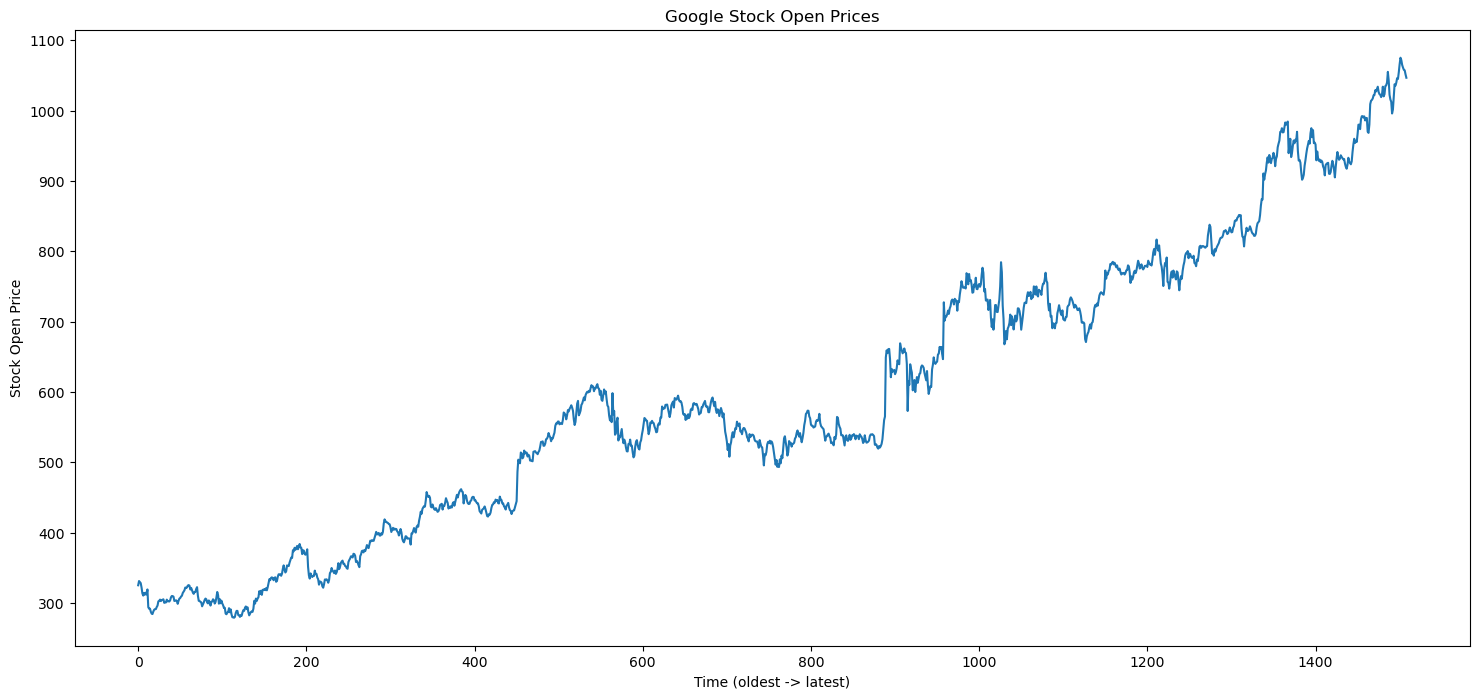

In [12]:
plt.figure(figsize=(18, 8))
plt.plot(dataset_train['Open'])
plt.title("Google Stock Open Prices")
plt.xlabel("Time (oldest -> latest)")
plt.ylabel("Stock Open Price")
plt.show()

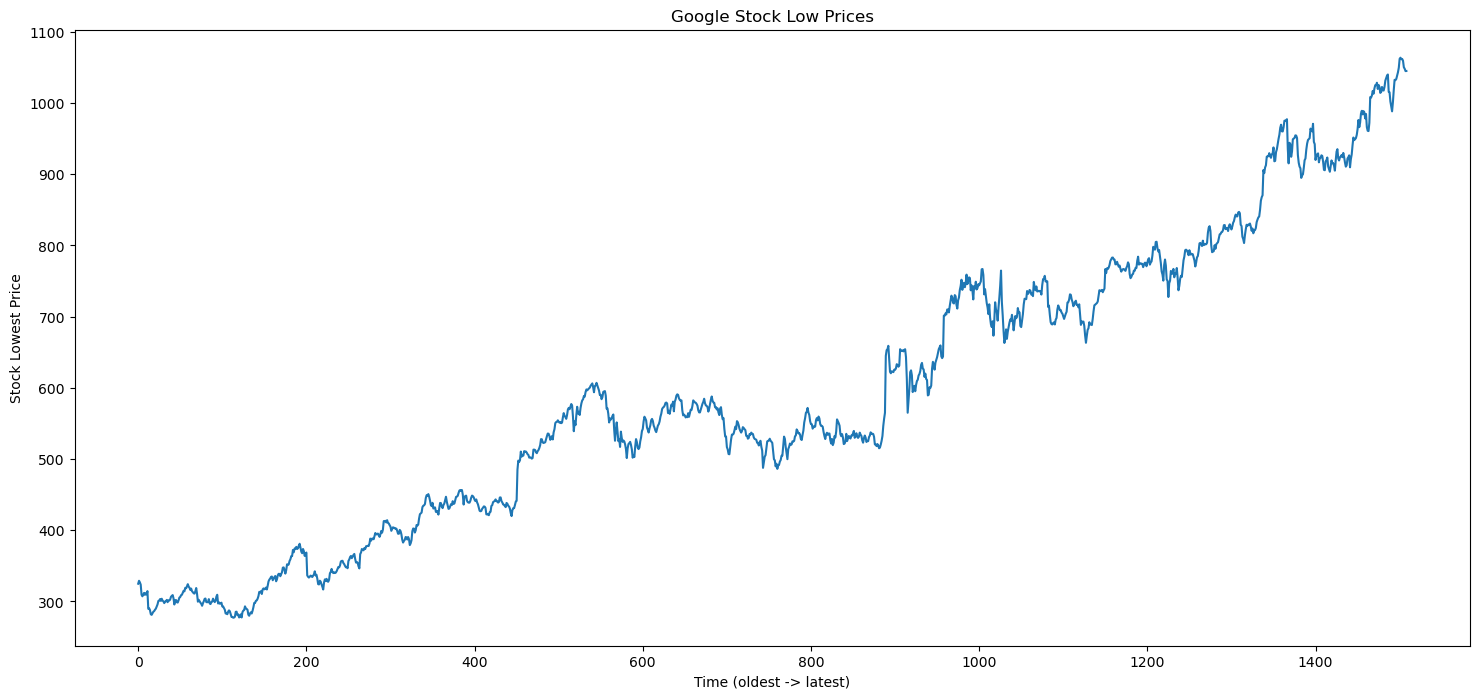

In [13]:
plt.figure(figsize=(18, 8))
plt.plot(dataset_train['Low'])
plt.title("Google Stock Low Prices")
plt.xlabel("Time (oldest -> latest)")
plt.ylabel("Stock Lowest Price")
plt.show()

# 5. Create & Fit Model

### 5.1 Create model

LSTM(units=50, return_sequences=True):

units=50: This LSTM layer has 50 neurons. These neurons will learn 50 different "features" or patterns from the previous 60 days' stock prices.

return_sequences=True: This is necessary for stacked LSTM layers. It ensures that this LSTM layer outputs the full sequence, not just the final output. This way, the next LSTM layer can continue to process the full sequence.

input_shape=(X_train.shape[1], 1): Specifies the shape of the input data, which is (60, 1). X_train.shape[1] is the number of timesteps (60), and 1 is the number of features (the stock price).

Dropout(rate=0.2):
Adds a Dropout layer with a dropout rate of 20%. Dropout helps prevent overfitting by randomly "dropping" (setting to zero) 20% of the neurons during training.

In [14]:
regressor = Sequential()
#add 1st lstm layer
regressor.add(LSTM(units = 50, return_sequences = True, input_shape = (X_train.shape[1], 1)))
regressor.add(Dropout(rate = 0.2))

##add 2nd lstm layer: 50 neurons
regressor.add(LSTM(units = 50, return_sequences = True))
regressor.add(Dropout(rate = 0.2))

##add 3rd lstm layer
regressor.add(LSTM(units = 50, return_sequences = True))
regressor.add(Dropout(rate = 0.2))

##add 4th lstm layer
regressor.add(LSTM(units = 50, return_sequences = False))
regressor.add(Dropout(rate = 0.2))

##add output layer
regressor.add(Dense(units = 1))

C:\Users\Saurav Lonkar\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [15]:
regressor.compile(optimizer = 'adam', loss = 'mean_squared_error')

### 5.2 Model fit

In [16]:
regressor.fit(x = X_train, y = y_train, batch_size = 32, epochs = 100)

Epoch 1/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 23s 155ms/step - loss: 0.0654
Epoch 2/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 174ms/step - loss: 0.0038
Epoch 3/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 171ms/step - loss: 0.0035
Epoch 4/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 175ms/step - loss: 0.0033
Epoch 5/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 171ms/step - loss: 0.0036
Epoch 6/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 171ms/step - loss: 0.0029
Epoch 7/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 172ms/step - loss: 0.0026
Epoch 8/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 168ms/step - loss: 0.0033
Epoch 9/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 165ms/step - loss: 0.0032
Epoch 10/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 179ms/step - loss: 0.0028
Epoch 11/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 163ms/step - loss: 0.0025
Epoch 12/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 174ms/step - loss: 0.0025
Epoch 13/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 161ms/step - loss: 0.0025
Epoch 14/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 176ms/step - loss: 0.0023
Epoch 15/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 8

# 6. Model evaluation

### 6.1 Read and convert

In [17]:
dataset_test = pd.read_csv('Google_Stock_Price_Test.csv')

In [18]:
dataset_test.head()

,Date,Open,High,Low,Close,Volume
0,02/01/2018,1048.339966,1066.939941,1045.229980,1065.000000,1237600
1,03/01/2018,1064.310059,1086.290039,1063.209961,1082.479980,1430200
2,04/01/2018,1088.000000,1093.569946,1084.001953,1086.400024,1004600
3,05/01/2018,1094.000000,1104.250000,1092.000000,1102.229980,1279100
4,08/01/2018,1102.229980,1111.270020,1101.619995,1106.939941,1047600


In [19]:
#keras only takes numpy array
real_stock_price = dataset_test.iloc[:, 1: 2].values
real_stock_price.shape

(125, 1)

### 6.2 Concat and convert

pd.concat() is a function from Pandas that concatenates (joins) two or more datasets along a specified axis.

(dataset_train['Open'], dataset_test['Open']): This concatenates the "Open" column from both the training (dataset_train) and testing (dataset_test) datasets. It combines the "Open" prices for both the training and testing periods into one large series.

axis=0: This specifies vertical concatenation, meaning the data will be stacked on top of each other, row-wise. If you had chosen axis=1, it would concatenate the data horizontally (column-wise), but here, vertical stacking is what you want.

2. Extract the last 60 days of stock prices for input
This calculates the starting index for the last 60 days of stock prices, which will be used as input for predicting the next day's stock price.

len(dataset_total) is the total number of data points in the combined training and testing data.

len(dataset_test) is the number of data points in the test set.

Subtracting 60 makes sure that you're selecting the most recent 60 days of data before the test set.

.values:
The .values attribute converts the Pandas Series into a NumPy array, which is required by most machine learning models.

Final result:
inputs is a NumPy array containing the last 60 days of "Open" prices from the combined dataset (train + test), which will be used for predicting stock prices in the test set.

This step ensures that the model can use the most recent stock prices (the last 60) to predict future stock prices for the test data.

In [20]:
#vertical concat use 0, horizontal uses 1
dataset_total = pd.concat((dataset_train['Open'], dataset_test['Open']), 
                          axis = 0)
##use .values to make numpy array
inputs = dataset_total[len(dataset_total) - len(dataset_test) - 60:].values

### 6.3 Reshape and scale

inputs.reshape(-1, 1): This reshapes the inputs array to ensure that it has 1 feature per timestep (which is necessary for LSTM models).

The -1 means that the size of the first dimension (the number of rows) will be inferred automatically based on the length of the data. In other words, it tells NumPy to reshape the array into a column where the number of rows is calculated based on the total length of the data, and each row contains a single feature (the stock price).

The 1 specifies that there will be 1 feature per timestep (in this case, the "Open" stock price).

After this reshaping, inputs will be a 2D array with the shape (number_of_days, 1), where each day has one feature (the stock price).

In [21]:
#reshape data to only have 1 col
inputs = inputs.reshape(-1, 1)

#scale input
inputs = sc.transform(inputs)

In [22]:
len(inputs)

185

### 6.4 Create test data strucutre

In [23]:
X_test = []
for i in range(60, len(inputs)):
    X_test.append(inputs[i-60:i, 0])
X_test = np.array(X_test)
#add dimension of indicator
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [24]:
X_test.shape

(125, 60, 1)

# 7. Model prediction

In [25]:
predicted_stock_price = regressor.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 281ms/step


sc.inverse_transform(predicted_stock_price):

sc: This refers to the scaler object (likely a MinMaxScaler or similar) that was previously fitted on the training data to scale the features (stock prices) to a specific range (like [0, 1]).

predicted_stock_price: This is the predicted stock prices returned by the LSTM model, but they are still in the scaled form (after being transformed by the scaler during training).

The inverse_transform() method is used to scale the predicted stock prices back to the original range, reversing the normalization step. This is important because the model was trained on scaled data, but you need the predictions to be in the original stock price range for proper interpretation.

In [26]:
#inverse the scaled value
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

### 7.1 Result visualization

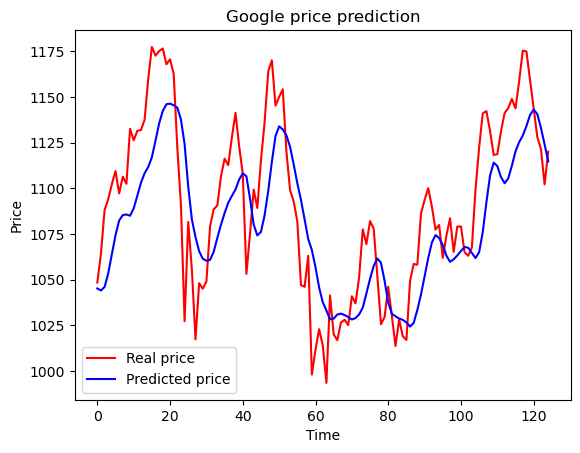

In [27]:
##visualize the prediction and real price
plt.plot(real_stock_price, color = 'red', label = 'Real price')
plt.plot(predicted_stock_price, color = 'blue', label = 'Predicted price')

plt.title('Google price prediction')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Actual stock prices (scaled back to original values)
actual_stock_price = dataset_test['Open'].values

# Calculate MAE
mae = mean_absolute_error(actual_stock_price, predicted_stock_price)

# Calculate MSE
mse = mean_squared_error(actual_stock_price, predicted_stock_price)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate R²
r2 = r2_score(actual_stock_price, predicted_stock_price)

# Print the results
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'R-squared (R²): {r2}')

Mean Absolute Error (MAE): 25.783486831875
Mean Squared Error (MSE): 963.756533885557
Root Mean Squared Error (RMSE): 31.044428387160828
R-squared (R²): 0.5746765886369958


🎯 Theory Behind Your Practical
4. Problem Statement
Use a Recurrent Neural Network (specifically LSTM) to predict Google stock prices based on historical data (2012–2017) and forecast stock price trends for the first half of 2018.

🧠 Core Concepts
1. Stock Price Dataset
Training Data: 2012 to 2017 (Google stock prices).
Testing Data: January 2018 to June 2018.
Features considered: Only "Open" price.
Columns available: Date, Open, High, Low, Close, Volume.

2. Why RNN? Why LSTM?
RNNs are perfect for time series and sequential data because they maintain memory of previous inputs.
LSTM (Long Short-Term Memory) solves vanishing gradient issues in standard RNNs and remembers long-term dependencies better.
LSTM Cells have:

Forget Gate
Input Gate
Output Gate
These help in controlling memory flow.

3. Data Preprocessing
Feature Scaling: Use MinMaxScaler to scale 'Open' prices to [0, 1].
Creating Time Windows:
For each prediction, use past 60 days stock prices as input (X_train).
The output (y_train) is the stock price on the next day.
Reshaping Input:
LSTM expects input in shape: (samples, time_steps, features).
Here, features = 1 (only the 'Open' price).
4. Model Architecture
LSTM Layers:
4 LSTM layers, each with 50 neurons.
return_sequences=True for all except last LSTM layer (to stack layers).
Dropout Layers:
Dropout (rate = 0.2) after each LSTM to prevent overfitting.
Output Layer:
Dense layer with 1 neuron (since we predict one price value).
Sequential Model flow:

Input → LSTM(50) → Dropout → LSTM(50) → Dropout → LSTM(50) → Dropout → LSTM(50) → Dropout → Dense(1)
5. Compilation and Training
Loss Function: Mean Squared Error (MSE) — because it’s a regression task.
Optimizer: Adam — efficient and works well without much tuning.
Training:

Batch Size: 32
Epochs: 100
Training loss decreased significantly by the end.

6. Model Evaluation and Prediction
Test set: Real 'Open' prices of Jan–June 2018.
Predict 'Open' prices for the test set.
Inverse transform the scaled predictions back to original scale.
7. Result Visualization
Plot Real Stock Prices (in red) vs Predicted Stock Prices (in blue).
Shows that the model captures the trend quite well.
💬 Important Viva Questions and Answers
Question	Answer
Why use LSTM for stock prediction?	Because stock data is sequential and LSTM can remember long-term patterns better than standard RNNs.
What is the purpose of Feature Scaling?	To ensure faster and more stable training by normalizing input values.
Why use 60 days as input window?	It was experimentally found to balance between model complexity and prediction accuracy.
What is the shape of input to LSTM?	(samples, time_steps, features) → e.g., (1449, 60, 1)
What is Dropout and why is it used?	Dropout randomly sets neurons to zero during training to prevent overfitting.
Why Mean Squared Error as loss function?	Because it is a standard loss function for continuous value prediction tasks.
What optimizer is used and why?	Adam — it's computationally efficient and adapts learning rates during training.
What does return_sequences=True mean?	It allows the LSTM layer to return the full sequence of outputs for stacking multiple LSTMs.
How is overfitting handled here?	By adding Dropout layers.
What is inverse_transform()?	It is used to bring back the normalized predicted values to the original scale.
📋 Quick Theory Flashcards (Before Entering Viva)
Dataset: Google stock prices (2012–2017 for training, 2018 for testing).
Model: 4 LSTM layers + Dropouts + Dense(1) output.
Loss: Mean Squared Error.
Optimizer: Adam.
Preprocessing: Feature Scaling (MinMaxScaler), Time Window = 60 days.
Prediction: Based on past 60 days to predict next day price.
